<img src="logo-utn.jpg" width="300" align="right">

# **Butterworth**
## Trabajo semanal 2
### Autor: Keila Korj
### Profesor: Mariano Llamedo Soria
### Ayudante de TPs: David Moharos

## ***Resumen***

En este trabajo se hará el diseño de un filtro pasa bajos $T_{LPF}(s)$ mediante aproximación de máxima planicidad, por caso, Butteworth, de orden 6.
Obteniendo módulo, fase y diagrama de polos y ceros de forma cualitativa. Para luego implementar una red normalizada que responda a la $T_{LPF}(s)$ mediante secciones de segundo orden (SOS) separadas por buffers en orden creciente de Q (Q1 < Q2 < Q3).
Finalmente se realizarán ajustes necesarios para obtener una ganancia de 10 dB en la banda de paso.

## ***Introducción***

Al obtener un pasa bajos por aproximación de máxima planicidad es sabido que:

$$ \left| T(j\omega) \right|^2 = \frac{1}{1 + \epsilon^2 \cdot \omega^{2n}} = T(s)\cdot T(-s) $$

Si planteamos $\omega = \frac{s}{j}$ y para el caso de butterworth $\epsilon^2 = 1$:

$$ \left| T(j\omega) \right|^2 = \frac{1}{1 + (\frac{s}{j})^{2n}} =  \frac{1}{1 + (-1)^{n} \cdot (s)^{2n}}$$

Pidiendo un orden $n=6$, quedaría:

$$ \left| T(j\omega) \right|^2 = \frac{1}{1 + s^{12}} $$

De modo que los polos se obtienen solo si $s=1$, pero ese resultado es posible si:

$$ 1 \cdot e^{j2n\theta} = 1 \cdot e^{j2k\pi} $$
Donde:
$$ \theta = \frac{2k\pi}{2n} = \frac{k\pi}{n} ; con \space k= 0, 1, 2, ..., 2n -1$$ 

Con los cual tendremos 12 polos distribuidos a lo largo del círulo de radio unidad ($w_o=1$) espaciados por $sep = \frac{\pi}{n} = \frac{\pi}{6}$

De este modo obtendremos $6$ polos en el semiplano izquierdo correspondientes a $T(s)$ y otros $6$ en el semiplano derecho pertenecientes a $T(-s)$ los cuales serán ignorados debido a la estabilidad del sistema.
Es así como finalmente se comprenden 3 pares de polos complejos conjugados con sus respectivos $\theta$ en:
$$\theta_3 = \frac{\pi}{12}$$
$$\theta_2 = \frac{\pi}{4}$$
$$\theta_1 = \frac{5 \cdot \pi}{12}$$
Siendo: 
$$Q=\frac{1}{2\cdot cos(\theta)}$$
De formal tal que a partir de los ángulos y de $w_o = 1$ podemos obtener la función transferencia del filtro como:

$$T_{LPF}(s) = \frac{1}{s^{2}+s \cdot \frac{1}{Q_1} + 1} \cdot \frac{1}{s^{2}+s \cdot \frac{1}{Q_2} + 1} \cdot \frac{1}{s^{2}+s \cdot \frac{1}{Q_3} + 1} = \frac{1}{s^{2}+s \cdot \frac{1}{2\cdot cos(\theta_1)} + 1} \cdot \frac{1}{s^{2}+s \cdot \frac{1}{2\cdot cos(\theta_2)} + 1} \cdot \frac{1}{s^{2}+s \cdot \frac{1}{2\cdot cos(\theta_3)} + 1}$$

Calculando:
$$Q_1 = \frac{1}{2\cdot cos(\theta_1)} = \frac{1}{2\cdot cos(\frac{5 \cdot \pi}{12})} = 0.5176$$
$$Q_2 = \frac{1}{2\cdot cos(\theta_2)} = \frac{1}{2\cdot cos(\frac{\pi}{4})} = \sqrt{2} = 0.7071$$
$$Q_3 = \frac{1}{2\cdot cos(\theta_3)} = \frac{1}{2\cdot cos(\frac{\pi}{12})} = 1.9318$$

Quedando finalmente:
**$$T_{LPF}(s) = \frac{1}{s^{2}+s \cdot \frac{1}{0.5176} + 1} \cdot \frac{1}{s^{2}+s \cdot \frac{1}{0.7071} + 1} \cdot \frac{1}{s^{2}+s \cdot \frac{1}{1.9318} + 1}$$**

De respuesta en módulo:
$$ |T(j\omega)| = \frac{1}{\sqrt{(1-\omega^2)^2 + (\frac{\omega}{Q_1})^2}} \cdot \frac{1}{\sqrt{(1-\omega^2)^2 + (\frac{\omega}{Q_2})^2}} \cdot \frac{1}{\sqrt{(1-\omega^2)^2 + (\frac{\omega}{Q_3})^2}} $$

Y fase:
$$ \phi(\omega) =  = -(\arctan\left( \frac{\omega/Q_1}{1-\omega^2} \right) + \arctan\left( \frac{\omega/Q_2}{1-\omega^2} \right) + \arctan\left( \frac{\omega/Q_3}{1-\omega^2} \right)) $$

A continuación se expondrá el gráfico de móudlo, fase, retardo y diagrama de polos y ceros de la transeferencia:

#### Aproximaciones de Butterworth

#### Butterworth_ord_6_rip_3_att_40

<IPython.core.display.Math object>

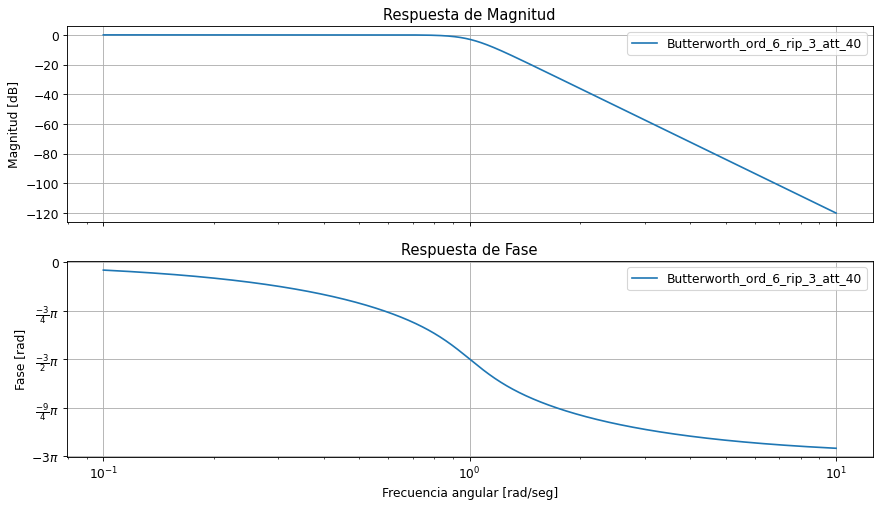

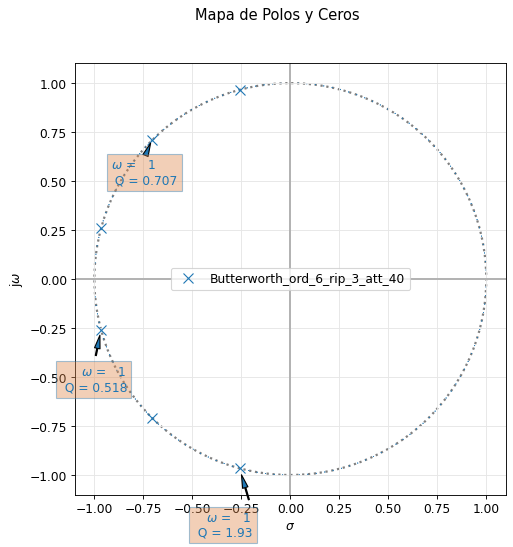

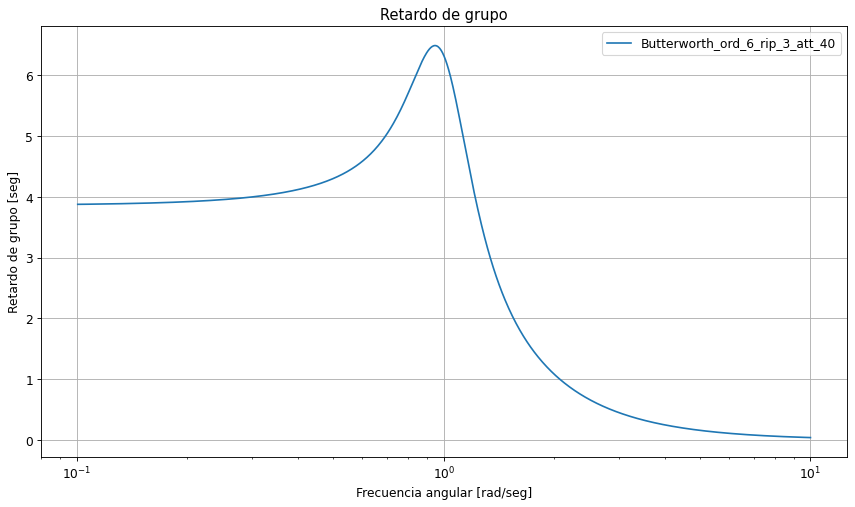

In [5]:
# Inicialización e importación de módulos

# Módulos externos
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig

fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi

fig_font_size = 11

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

# Ahora importamos las funciones de PyTC2

from pytc2.sistemas_lineales import analyze_sys, pretty_print_bicuad_omegayq, tf2sos_analog, pretty_print_SOS

from pytc2.general import print_subtitle


def sim_aprox(aproxs, orders2analyze, ripple, attenuation):

    all_sys = []
    filter_names = []

    for (this_aprox, this_order, this_ripple, this_att) in zip(aproxs, orders2analyze, ripple, attenuation):

        if this_aprox == 'Butterworth':

            z,p,k = sig.buttap(this_order)

            eps = np.sqrt( 10**(this_ripple/10) - 1 )
            num, den = sig.zpk2tf(z,p,k)
            num, den = sig.lp2lp(num, den, eps**(-1/this_order))

            z,p,k = sig.tf2zpk(num, den)

        elif this_aprox == 'Chebyshev1':

            z,p,k = sig.cheb1ap(this_order, this_ripple)

        elif this_aprox == 'Chebyshev2':

            z,p,k = sig.cheb2ap(this_order, this_att)

        elif this_aprox == 'Bessel':

            z,p,k = sig.besselap(this_order, norm='delay')

        elif this_aprox == 'Cauer':

            z,p,k = sig.ellipap(this_order, this_ripple, this_att)


        num, den = sig.zpk2tf(z,p,k)

        
        all_sys.append(sig.TransferFunction(num,den))

        this_label = this_aprox + '_ord_' + str(this_order) + '_rip_' + str(this_ripple)+ '_att_' + str(this_att)
        
        print_subtitle(this_label)
        # factorizamos en SOS's
        this_sos = tf2sos_analog(num, den)
        
        pretty_print_SOS(this_sos, mode='omegayq')
        
        filter_names.append(this_label)
        
    # el caracter "_" descarta la salida de la función
    _ = analyze_sys( all_sys, filter_names )

    return( all_sys, filter_names )


aprox_name = 'Butterworth'
#aprox_name = 'Chebyshev1'
#aprox_name = 'Chebyshev2'
#aprox_name = 'Bessel'
#aprox_name = 'Cauer'

# parametrizamos el orden para cada aproximación
orders2analyze = [6]

# Mismo requerimiento de ripple y atenuación
aproxs = [aprox_name] * len(orders2analyze)
ripple = [3] * len(orders2analyze) # dB \alpha_{max} <-- Sin parametrizar, lo dejo en Butterworth
attenuation = [40] * len(orders2analyze) # dB \alpha_{min} <-- Sin parametrizar, att fija


print_subtitle('Aproximaciones de Butterworth')

( all_sys, filter_names ) = sim_aprox(aproxs, orders2analyze, ripple, attenuation)

A partir de la simulación numérica podemos confirmar que los cálculos realizados matemáticamente son correctos, puesto que:
- El modulo responde a un filtro pasa bajos ya que cuando $\omega \to 0$ el módulo es $1$, cuando $\omega \to \infty$ el módulo es 0 y en $\omega = \omega_0 = 1$ $|T(j\omega)| = Q_1 \cdot Q_2 \cdot Q_3$
- La fase coincide con las  aportadas por los polos al observar el diagrama de polos en $\omega \to 0$ todos los polos aportan $0$ en total debido a la compensación respectiva del polo conjugado. Para $\omega \to \infty$ la fase es $-3\pi$ dado que al ser $6$ polos todos aportan $-\frac{\pi}{2}$ y finalmente para $\omega = \omega_0 = 1$ la fase es $-\frac{3\pi}{2}$ lo cual coincide con la mitad del recorrido de la fase para el $\omega_0$.
- Los valores de $Q$ son coincidentes con los obtenidos en los cálculos.

## ***Implementación de red normalizada con SOS's***

A partir de la transferencia por aproximación de máxima planicidad por caso butterworth, se implementará una red normalizada haciendo uso de 3 SOS's (second order sections) correspondientes a cada par de polos complejos conjugados con sus respectivos $Q$ conectados de forma creciente y separados por buffers.

Donde para $Q_1 = 0.5176$ se hará uso de un *Sallen-Key*, para $Q_2= 0.7071$ un *KHN* y para $Q_3 = 1.9318$ un *MFB*, de forma tal que

$$T_{LPF}(s) = T_{sk}(s) \cdot T_{KHN}(s) \cdot T_{MFB}(s)$$

# *Sallen-Key*


<div align="center">
    <img src="sallen-key.png" width="400">
</div>

*Esquema de Sallen-Key pasa bajos*

Donde a través del método de nodos se obtuvo la siguiente transferencia:

$$ T_{sk}(s) = \frac{\frac{G_1 \cdot G_2}{C_1 \cdot C_2} \cdot \frac{G_3 + G_4}{G_4}}{ s^{2} + s \cdot (\frac{G_1 + G_2}{C_2} - \frac{G_2 \cdot G_3}{C_1 \cdot G_4}) + \frac{G_1 \cdot G_2}{C_1 \cdot C_2}}$$

Donde al tomar $G_1 = G_2 = G = \frac{1}{R}$, $C_1 = C_2 = C$ y como norma de impedancia $\Omega_z = \frac{1}{G} = R$, queda:

$$ T_{sk}'(s) = \frac{\frac{1}{C'^{2}} \cdot \frac{G_3' + G_4'}{G_4'}}{ s^{2} + s \cdot (\frac{2}{C'} - \frac{G_3'}{C' \cdot G_4'}) + \frac{1}{C'^{2}}}$$

Luego normalizando por frencuencia $\to \Omega_{w_0} = \frac{1}{C'}$ tal que $\omega_{0_N} = \frac{1}{C'^{2}} = 1, con lo cual:

$$ T_{sk}'(s) = \frac{\frac{G_3' + G_4'}{G_4'}}{ s^{2} + s \cdot (2 - \frac{G_3'}{G_4'}) + 1}$$
Correspondiendo a filtro pasa bajos de forma:

$$T(s) = \frac{k \cdot \omega_0}{s^{2} + s \cdot \frac{\omega_0}{Q} + \omega_0}$$

Siendo
$$\omega_{0_N} = 1$$
$$\frac{1}{Q_1} = 2- \frac{G_3'}{G_4'}$$
$$k =\frac{G_3' + G_4'}{G_4'}$$

y
$$\frac{G_3'}{G_4'} = k - 1$$ 

Quedando $Q = \frac{1}{3-k}$ notando de esta manera una gran dependencia de $Q$ con la ganancia $k$, de modo que definimos el $k$ para el $Q_1 = 0.5176$ requerido.
Por ende
$$k= 1.068 = 1 + \frac{G_3}{G_4} = 1 + \frac{R_4}{R_3}$$

$$R_4 = 0.068 \cdot R_3$$

Y es así como obtenemos todos los parametros del *Sallen-Key* para las condiciones requeridas.

# *Kerwin–Huelsman–Newcomb (KHN)*


<div align="center">
    <img src="khn.png" width="400">
</div>

*Esquema del KHN*

Para el cálculo de esta transferencia se tomómo directamente que:

$$R_1=R_2=R_3=R_4=R_5=R$$
y
$$C_1=C_2=C$$

Con lo cual la transferencia mediante el método de nodos es:

$$T_{KHN}(s) = -\frac{\frac{G^{2}}{C^{2}}}{s^{2} + s \cdot \frac{3 \cdot G \cdot G_6}{C \cdot (G_6 + G_7)} + \frac{G^{2}}{C^{2}}}$$

Tomando como norma de impedancia $ \Omega_z = \frac{1}{G} = R$:
$$ T_{KHN}'(s) = - \frac{\dfrac{1}{C'^2}}{s^2 + s \cdot \dfrac{3 \cdot G_6'}{C' \cdot (G_6' + G_7')} + \dfrac{1}{C'^2}} $$

Y normalizando por frecuencia $\to \Omega_{w_0} = \frac{1}{C'}$

$$ T_{KHN}'(s) = - \frac{1}{s^2 + s \cdot \dfrac{3 \cdot G_6'}{G_6' + G_7'} + 1} $$

Respetando la forma de un pasa bajos donde:

$$T(s) = \frac{k \cdot \omega_0}{s^{2} + s \cdot \frac{\omega_0}{Q} + \omega_0}$$

Siendo
$$\to \omega_{0_N} = 1$$
$$\to \frac{1}{Q_2} = \dfrac{3 \cdot G_6'}{G_6' + G_7'}$$
$$\to k =1$$

Por ende
$$Q_2 = \frac{G_6 + G_7}{3 \cdot G_6} = 0.7071$$
$$\frac{1}{3} + \frac{G_7}{G_6} = 0.7071$$
$$R_6 = 0.3737 \cdot R_7$$

Obteniendo así todos los componentes para las condiciones requeridas.

# *Multiple Feedback (MFB)*

<div align="center">
    <img src="mfb.png" width="400">
</div>

*Esquema del MFB*

En una primera instancia se intentó obtenener la transferencia tomando directamente $R_1 = R_2 = R$ y $C_1 = C_2 = C$, sin embargo, fue notorio que para obtener un $Q$ alto como el caso de $Q_3 = 1.9318$ se necesitaría una resistencia negativa, lo cual no sería correcto. Este error llevó a la conclusión de que la configuración *MFB* es mucho más estricta con la elección de parámetros en comparación con la anteriores. 
Es así como tomando todos los componentes de valores distintos se llega a:

$$T_{MFB}(s) = -\frac{\frac{G_2 \cdot G_3}{C_1 \cdot C_2}}{s^{2} + s \cdot \frac{G_1 + G_2 + G_3}{C_1)} + \frac{G_1 \cdot G_2}{C_1 \cdot C_2}}$$

Donde para respetar la forma de un pasa bajos:

$$T(s) = \frac{k \cdot \omega_0}{s^{2} + s \cdot \frac{\omega_0}{Q} + \omega_0}$$

$$T_{MFB}(s) = - \frac{G_3}{G_1} \cdot\frac{\frac{G_1 \cdot G_2}{C_1 \cdot C_2}}{s^{2} + s \cdot \frac{G_1 + G_2 + G_3}{C_1)} + \frac{G_1 \cdot G_2}{C_1 \cdot C_2}}$$

Es aquí donde se decidió tomar a $G_1 = G_2 = G_3 = G = \frac{1}{R}$ siendo esta misma la norma de impedancia ($\Omega_z = R = \frac{1}{G}$)

$$T_{MFB}'(s) = -\frac{\frac{1}{C_1' \cdot C_2'}}{s^{2} + s \cdot \frac{3}{C_1')} + \frac{1}{C_1' \cdot C_2'}}$$

Y normalizando por frecuencia $\to \Omega_{w_0} = \sqrt{\frac{1}{C_1' \cdot C_2'}}$, con lo cual

$$\omega_{0_N} = \frac{1}{C_1' \cdot C_2'} = 1$$
Entonces
$$C_1' = 1/C_2'$$
Quedando
$$T_{MFB}'(s) = -\frac{1}{s^{2} + s \cdot 3 \cdot C_2' + 1}$$

Siendo
$$\to \omega_{0_N} = 1$$
$$\to \frac{1}{Q_3} = 3 \cdot C_2' = \frac{1}{1.9318}$$
$$\to k =1$$

Por lo tanto
$$C_2' = 0.1725$$

y

$$C_1' = \frac{1}{C_2'} = 5.7971$$

Obteniendo finalmente todos los componentes para las condiciones requeridas.

## ***Simulación circuital***

<div align="center">
    <img src="red_pre10dB.png" width="900">
</div>

*Red de 3 SOS's implementada y normalizadas (**Sallen-key**, **KHN**, **MFB**) separadas por buffers*

En la imagen se pueden observar las 3 etapas implementadas, donde el grafico de la transferencia es:

<div align="center">
    <img src="graf_pre10dB.png" width="900">
</div>

*Gráfico de módulo y fase de la transferencia de la red normalizada (punteado: fase / trazo continuo:módulo)*

Al observa el gráfico podemos obtener la siguientes conclusiones:
- Los gráficos obtenidos en la simulación numérica se ven iguales a los de la simulación circuital.
- Se aprecia una banda de paso casi plana que es justamente lo que se quería lograr con la aproximación de máxima planicidad.
- En la frecuencia de corte $f_0 = 159mHz$ se obrserva una fase de $-269.69°$ lo cual es casi la mitad del recorrido entre $0°$ y $-540°$

<div align="center">
    <img src="graf2_pre10dB.png" width="300">
</div>

*Tabla del cursor aplicado 1 década más tarde de la $f_0$*

- Como puede apreciarse en la imagen para una década posterior a $f_0$ el módulo toma $-119.51dB$ que comparado con los $-6.19dB$ pertenecientes a cuando $f = f_0$ de observa una pendiente de aproximadamente $113\frac{dB}{dec}$ lo cual es un valor cercano a los $120 \frac{dB}{dec}$ esperables de un butterworth de orden 6.


<div align="center">
    <img src="graf3_pre10dB.png" width="300">
</div>

*Tabla del cursor aplicado en bajas frecuencias*

- Notar que para frecuencias bajas el módulo no es exactamente $0 \space dB$ esto es debido a que si bien el *KHN* y el *MFB* fueron diseñados para tener ganancia unitaria, puesto a la dependencia existente entre el $k$ y el $Q$ en el *Sallen-Key*, para el $Q_1$ requerido se obtenía una $k_1 = 1.068$ expresado en veces, con lo cual, $k_{1_{dB}} = 0.57dB$ y ,por ende, la ganancia observada en el gráfico es aquella que fue proporcionada por la primer etapa.

## ***Ajustes para 10dB de ganancia***

Como se ha hecho mención anteriormente, el *MFB* es más sensible a la variación de parametros para llegar a $Q$ altos. Por otra parte el *Sallen-Key* no puede tener una modificación cualquiera de la ganancia dado que esta afecta directamente al $Q$.
Por estas razones que se decidió mantener intactas las etapas $SOS_1$ y $SOS_3$ correspondientes al *Sallen_key* y al *MFB* respectivamente, de modo que solo se modificó el **KHN**.

Para ello se decidió tomar $R_2= R_3=R_4=R_5=R = \frac{1}{G}$ y $C_1=C_2 = C$, dejando a $R_1$, $R_6$ y $R_7$ como distintas.
De este modo se obtuvo la siguiente transefrencia

$$T_{KHN}(s) = -\frac{\frac{G^{2} \cdot G_1}{C^{2}}}{s^{2} + s \cdot \frac{G \cdot G_6 \cdot (2G + G_1)}{C \cdot (G_6 + G_7)} + \frac{G^{3}}{C^{2}}}$$

De modo que para respetar la forma de un pasa bajos
$$T(s) = \frac{k \cdot \omega_0}{s^{2} + s \cdot \frac{\omega_0}{Q} + \omega_0}$$

Entonces
$$T_{KHN}(s) = - \frac{G_1}{G} \frac{\frac{G^{3} \cdot G_1}{C^{2}}}{s^{2} + s \cdot \frac{G \cdot G_6 \cdot (2G + G_1)}{C \cdot (G_6 + G_7)} + \frac{G^{3}}{C^{2}}}$$

Eligiendo como norma de impedancia $\Omega_z = R = \frac{1}{G}$ queda:

$$T_{KHN}(s) = -  \frac{\frac{G_1'}{C'^{2}}}{s^{2} + s \cdot \frac{G_6' \cdot (2 + G_1')}{C' \cdot (G_6' + G_7')} + \frac{1}{C'^{2}}}$$

Y normalizando por frecuencia $\to \Omega_{w_0} = \frac{1}{C'}$
$$T_{KHN}(s) = -  \frac{G_1'}{s^{2} + s \cdot \frac{G_6' \cdot (2 + G_1')}{G_6' + G_7'} + 1}$$

Siendo
$$\to \omega_{0_N} = 1$$
$$\to \frac{1}{Q_3} = \frac{G_6' \cdot (2 + G_1')}{G_6' + G_7'} = 1.9318$$
$$\to k_{KHN} = G_1'$$

Con los cual si se quería obtener un $k_{TOT_{dB}} = 10 \space dB$ entonces $k_{TOT_{veces}} = 3.16$, con lo cual

$$k_{sk} \cdot k_{KHN} \cdot k_{MFB} = 3.16$$

Siendo
$$k_{sk} = 1.068$$
$$k_{MFB} = 1$$
Entonces 
$$k_{KHN} = 2.9588 = G_1'$$
Por ende
$$ R_1' = \frac{1}{G_1'}=0.3379$$

Y para obtener el Q deseado

$$Q_3 = \frac{1}{2 + G_1'} + \frac{G_7'}{G_6'}$$

Entonces
$$R_6 = 0.5056 \cdot R_7$$

Obteniendo así todo los componentes para las condiciones requeridas

### ***Simulación circuital para ganancia de 10dB***

<div align="center">
    <img src="red_en10dB.png" width="900">
</div>

*Red implementada y normalizada para obtener 10 dB de ganancia*

A continuación se presenta el gráfico:

<div align="center">
    <img src="graf_en10dB.png" width="900">
</div>

*Gráfico de módulo y fase donde se botuvieron 10 dB de ganancia (Punteado: fase / Trazo continuo: módulo)*

- Como puede observarse el gráfico está "levantado" respeto al conseguido anteriormente.
- En $f_0$ volvemos a obtener una fase de $269.71°$ que coincide con la mitad del recorrido en la fase.
- La forma sigue respetando la de un pasa bajos.

<div align="center">
    <img src="graf2_en10dB.png" width="300">
</div>

*Tabla de cursor para $f= 10mHz$*

- Es notable que si nos movemos en la bajas frecuencia obtenemos un módulo de casi $10 \space dB$ que corresponde a la ganancia que queríamos obtener.

<div align="center">
    <img src="graf3_en10dB.png" width="300">
</div>

*Tabla del cursor aplicado 1 década más tarde de la $f_0$*

- Si nos movemos y década luego de la $f_0$ se ve que el módulo nos da $-110.33 \space dB$, que si lo comparamos con los $-0.3 \space dB$ de $f = f_0$ resulta en una pendiente de aproximadamente $110 \frac{dB}{dec}$ que es casi una pendiente de $120 \frac{dB}{dec}$ esperables de un butterworth de orden 6.



## ***Conclusión***
Se logró hacer una implementación y diseño adecuado para un filtro pasa bajos mediante la aproximación de máxima planicidad por caso *Butterworth* consiguiendo corroborar el desarrollo matemático mediante simulacion (numérica y circuital) además de lograr hacer ajustes según los requerimientos específicados.